<a href="https://colab.research.google.com/github/deepsarka/Market-Sentiment-Trader-Performance-Analysis/blob/main/Market_Sentiment__%26__Trader__Performance__Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load both datasets
fear = pd.read_csv("/content/fear_greed_index.csv")
hist = pd.read_csv("/content/historical_data.csv", engine="python", on_bad_lines='skip')

In [ ]:
# number of rows/columns
fear.shape

(2644, 4)

In [ ]:
hist.shape

(211224, 16)

In [ ]:
# missing values
fear.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
# Remove duplicates
fear = fear.drop_duplicates(subset='date').reset_index(drop=True)

In [ ]:
# missing values
hist.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
# Remove duplicates
hist = hist.drop_duplicates().reset_index(drop=True)

In [ ]:
# Convert date column to proper datetime
fear['date'] = pd.to_datetime(fear['date'])

# keep only date, remove time
hist['date'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
hist['date'] = hist['date'].dt.normalize()

In [ ]:
# Rename columns for easier use
hist.columns = hist.columns.str.strip()
hist = hist.rename(columns={
    'Account': 'account',
    'Coin': 'coin',
    'Execution Price': 'exec_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Start Position': 'start_pos',
    'Direction': 'direction',
    'Closed PnL': 'closed_pnl',
    'Fee': 'fee',
    'Trade ID': 'trade_id'
})

In [ ]:
# Create Key Metrics
# Daily PnL per trader
daily_pnl = hist.groupby(['date', 'account'])['closed_pnl'].sum().reset_index()
daily_pnl.columns = ['date', 'account', 'daily_pnl']
daily_pnl

,date,account,daily_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
...,...,...,...
2336,2025-05-01,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,1449.529436
2337,2025-05-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,102460.171640
2338,2025-05-01,0xbaaaf6571ab7d571043ff1e313a9609a10637864,1.860320
2339,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,-113601.020138


In [ ]:
# Win rate per trader
daily_pnl['is_win'] = daily_pnl['daily_pnl'] > 0
win_rate = daily_pnl.groupby('account').agg(
    total_days=('daily_pnl', 'count'),
    win_days=('is_win', 'sum'),
    total_pnl=('daily_pnl', 'sum'),
    avg_pnl=('daily_pnl', 'mean')
).reset_index()
win_rate['win_rate'] = (win_rate['win_days'] / win_rate['total_days'] * 100).round(2)
win_rate

,account,total_days,win_days,total_pnl,avg_pnl,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,24,16,1.600230e+06,66676.242499,66.67
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,52,29,4.788532e+04,920.871548,55.77
2,0x271b280974205ca63b716753467d5a371de622ab,12,8,-7.043619e+04,-5869.682610,66.67
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,162,144,1.324648e+05,817.684040,88.89
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,69,54,1.686580e+05,2444.318913,78.26
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,43,14,-3.120360e+04,-725.665116,32.56
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,46,25,1.445692e+04,314.280855,54.35
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,28,15,5.349625e+04,1910.580259,53.57
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,20,10,1.995056e+05,9975.279637,50.00
9,0x430f09841d65beb3f27765503d0f850b8bce7713,28,7,4.165419e+05,14876.495441,25.00


In [ ]:
# Average trade size per day
daily_size = hist.groupby('date')['size_usd'].mean().reset_index()
daily_size.columns = ['date', 'avg_size_usd']
daily_size

,date,avg_size_usd
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667
...,...,...
475,2025-04-27,1446.699377
476,2025-04-28,18944.830667
477,2025-04-29,15198.177289
478,2025-04-30,11405.102291


In [ ]:
# Number of trades per day
daily_trades = hist.groupby('date')['trade_id'].count().reset_index()
daily_trades.columns = ['date', 'num_trades']
daily_trades

,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3
...,...,...
475,2025-04-27,337
476,2025-04-28,1379
477,2025-04-29,2243
478,2025-04-30,1113


In [ ]:
# Long/Short ratio per day
hist['is_long'] = hist['side'].str.upper() == 'BUY'
daily_ls = hist.groupby('date').agg(
    longs=('is_long', 'sum'),
    total=('is_long', 'count')
).reset_index()
daily_ls['long_ratio'] = (daily_ls['longs'] / daily_ls['total']).round(3)
daily_ls

,date,longs,total,long_ratio
0,2023-05-01,3,3,1.000
1,2023-12-05,7,9,0.778
2,2023-12-14,5,11,0.455
3,2023-12-15,2,2,1.000
4,2023-12-16,3,3,1.000
...,...,...,...,...
475,2025-04-27,209,337,0.620
476,2025-04-28,652,1379,0.473
477,2025-04-29,1105,2243,0.493
478,2025-04-30,838,1113,0.753


In [ ]:
fear['sentiment'] = fear['classification']
print(fear['sentiment'].value_counts())

sentiment
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [ ]:
# Merge Datasets by Date

merged = daily_pnl.merge(
    fear[['date', 'value','sentiment']],
    on='date',
    how='inner'
)

merged = merged.merge(daily_trades, on='date', how='left')
merged = merged.merge(daily_size,   on='date', how='left')
merged = merged.merge(daily_ls[['date', 'long_ratio']], on='date', how='left')

In [ ]:
merged

,date,account,daily_pnl,is_win,value,sentiment,num_trades,avg_size_usd,long_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,False,63,Greed,3,159.000000,1.000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,False,75,Extreme Greed,9,5556.203333,0.778
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,False,72,Greed,11,10291.213636,0.455
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,False,70,Greed,2,5304.975000,1.000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,False,67,Greed,3,5116.256667,1.000
...,...,...,...,...,...,...,...,...,...
2335,2025-05-01,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,1449.529436,True,53,Neutral,1230,8715.642699,0.558
2336,2025-05-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,102460.171640,True,53,Neutral,1230,8715.642699,0.558
2337,2025-05-01,0xbaaaf6571ab7d571043ff1e313a9609a10637864,1.860320,True,53,Neutral,1230,8715.642699,0.558
2338,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,-113601.020138,False,53,Neutral,1230,8715.642699,0.558


# **Analysis**

In [ ]:
# PnL & Win Rate by Sentiment
# Order of sentiment
ORDER = ['Fear', 'Neutral', 'Greed']

# Create win flag
merged['is_win'] = merged['daily_pnl'] > 0

# PnL Stats
pnl_stats = merged.groupby('sentiment')['daily_pnl'].agg(
    mean='mean',
    median='median',
    std='std'
).reindex(ORDER).round(2)

pnl_stats.columns = ['Mean PnL ($)', 'Median PnL ($)', 'Std Dev']

# Win Rate
wr_stats = (merged.groupby('sentiment')['is_win']
            .mean() * 100).reindex(ORDER).round(2)

wr_stats = wr_stats.rename('Win Rate (%)')

# Drawdown Proxy (avg loss)
dd_stats = (merged[merged['daily_pnl'] < 0]
            .groupby('sentiment')['daily_pnl']
            .mean().reindex(ORDER).round(2))

dd_stats = dd_stats.rename('Avg Loss ($)')

# Combine all stats
final_stats = pd.concat([pnl_stats, wr_stats, dd_stats], axis=1)

print("✅ Sentiment Performance Summary")
print(final_stats)

✅ Sentiment Performance Summary
           Mean PnL ($)  Median PnL ($)   Std Dev  Win Rate (%)  Avg Loss ($)
sentiment                                                                    
Fear            5328.82          107.89  31659.77         60.48      -6071.37
Neutral         3438.62          167.55  17447.86         62.23      -6879.44
Greed           3318.10          158.21  30599.04         61.11     -16562.52


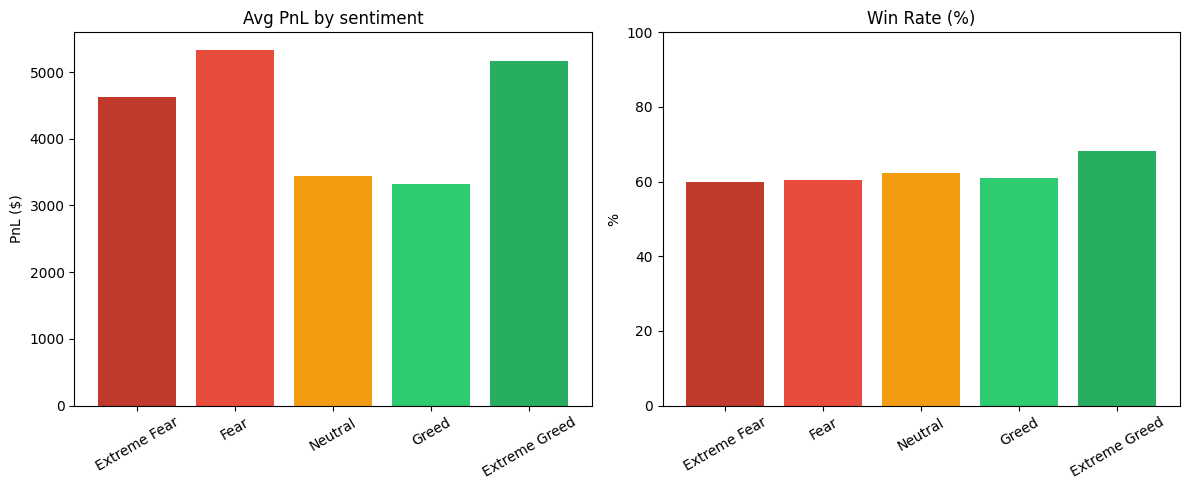

In [ ]:
# Chart 1 — PnL & Win Rate by Sentiment
# Order (use your sentiment levels)
ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Simple colors
COLORS = {
    'Extreme Fear': '#c0392b',
    'Fear': '#e74c3c',
    'Neutral': '#f39c12',
    'Greed': '#2ecc71',
    'Extreme Greed': '#27ae60'
}

bar_colors = [COLORS.get(x, 'gray') for x in ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mean PnL
avg_pnl = merged.groupby('sentiment')['daily_pnl'].mean().reindex(ORDER)

axes[0].bar(ORDER, avg_pnl, color=bar_colors)
axes[0].set_title('Avg PnL by sentiment')
axes[0].set_ylabel('PnL ($)')
axes[0].tick_params(axis='x', rotation=30)

# Win Rate
wr = merged.groupby('sentiment')['is_win'].mean() * 100
wr = wr.reindex(ORDER)

axes[1].bar(ORDER, wr, color=bar_colors)
axes[1].set_title('Win Rate (%)')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### **Key Insight:**

 - **Fear days** actually produce the HIGHEST average PnL. This is counterintuitive — traders make MORE money on Fear days than Neutral/Greed days. This suggests experienced traders on Hyperliquid are contrarian — they buy during fear and profit when prices recover.

 - **Win rate** is HIGHEST on Extreme Greed days (~68%), meaning traders win more frequently when the market is euphoric. However, win rate differences are small (60–68%) across all sentiments — sentiment alone doesn't dramatically change how often traders win.

In [ ]:
# Trader Behavior by Sentiment
behavior = merged.groupby('sentiment').agg(
    avg_trades_per_day = ('num_trades',  'mean'),
    avg_size_usd       = ('avg_size_usd','mean'),
    avg_long_ratio     = ('long_ratio',  'mean')
).reindex(ORDER).round(3)
behavior

,avg_trades_per_day,avg_size_usd,avg_long_ratio
sentiment,,,
Extreme Fear,2106.850,5208.084,0.494
Fear,1318.130,7743.220,0.503
Neutral,1235.867,5274.791,0.495
Greed,809.318,5537.023,0.477
Extreme Greed,744.517,3679.785,0.460


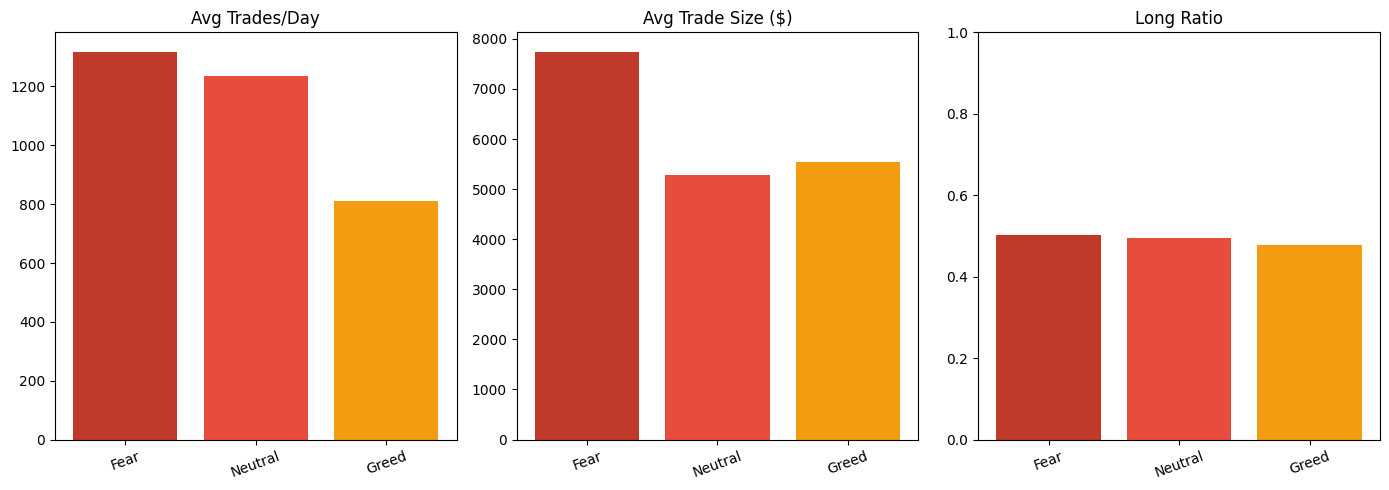

In [ ]:
# Chart 2 — Behavior by Sentiment
# Use your sentiment order
ORDER = ['Fear', 'Neutral', 'Greed']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Metrics to plot
metrics = [
    ('num_trades', 'Avg Trades/Day'),
    ('avg_size_usd', 'Avg Trade Size ($)'),
    ('long_ratio', 'Long Ratio')
]

for ax, (col, title) in zip(axes, metrics):

    vals = merged.groupby('sentiment')[col].mean().reindex(ORDER)

    ax.bar(ORDER, vals, color=bar_colors)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

    # Special case for long ratio
    if col == 'long_ratio':
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


### **key insight**

- **Traders are MOST active on Fear days (1,300 trades/day)** and least active on Greed days (~810). This is the opposite of what most people expect — instead of panic-selling and staying out, traders are actually **rushing into the market during fear**, likely trying to catch bottoms.

- **Traders place their LARGEST positions on Fear days (7,700)** — nearly 45% bigger than on Greed days. This is a classic **"dip buying" behavior** — traders bet big when prices drop, expecting a recovery. Combined with the high trade frequency, Fear days see both more trades AND bigger bets.

- **Long ratio is nearly identical (~0.48–0.50) across all sentiments**. Traders maintain a roughly **50/50 long-short balance** regardless of market mood — suggesting Hyperliquid traders are disciplined hedgers who don't blindly go long during greed or short during fear.

In [ ]:
# Trader Segmentation
# Trader Summary
trader_stats = hist.groupby('account').agg(
    total_trades = ('trade_id',   'count'),
    total_pnl    = ('closed_pnl', 'sum'),
    avg_pnl      = ('closed_pnl', 'mean'),
    avg_size     = ('size_usd',   'mean'),
    active_days  = ('date',       'nunique')
).reset_index()

# Trades per day
trader_stats['trades_per_day'] = (
    trader_stats['total_trades'] / trader_stats['active_days']
).round(2)

# Win Rate
wins  = hist[hist['closed_pnl'] > 0].groupby('account')['trade_id'].count()
total = hist.groupby('account')['trade_id'].count()
trader_stats['win_rate_pct'] = (
    wins.div(total) * 100
).reindex(trader_stats['account'].values).fillna(0).values.round(2)

# Frequency Segment
trader_stats['freq_segment'] = pd.cut(
    trader_stats['trades_per_day'],
    bins=[0, 10, 50, np.inf],
    labels=['Low\n(<10/day)', 'Medium\n(10-50/day)', 'High\n(>50/day)']
)

# Performance Segment
q75 = trader_stats['total_pnl'].quantile(0.75)
trader_stats['perf_segment'] = pd.cut(
    trader_stats['total_pnl'],
    bins=[-np.inf, 0, q75, np.inf],
    labels=['Loss Maker', 'Average', 'Top Trader']
)

# Trade Size Segment
p33 = trader_stats['avg_size'].quantile(0.33)
p66 = trader_stats['avg_size'].quantile(0.66)

trader_stats['size_segment'] = pd.cut(
    trader_stats['avg_size'],
    bins=[0, p33, p66, np.inf],
    labels=[
        f'Small\n(<${p33:,.0f})',
        f'Medium\n(${p33:,.0f}-${p66:,.0f})',
        f'Large\n(>${p66:,.0f})'
    ]
)


trader_stats

,account,total_trades,total_pnl,avg_pnl,avg_size,active_days,trades_per_day,win_rate_pct,freq_segment,perf_segment,size_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,16159.576734,24,159.08,35.96,High\n(>50/day),Top Trader,"Large\n(>$4,974)"
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,1653.226327,52,140.00,44.27,High\n(>50/day),Average,"Small\n(<$2,249)"
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,8893.000898,12,317.42,30.19,High\n(>50/day),Loss Maker,"Large\n(>$4,974)"
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,507.626933,162,82.17,43.86,High\n(>50/day),Average,"Small\n(<$2,249)"
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,3138.894782,69,46.94,51.99,Medium\n(10-50/day),Average,"Medium\n($2,249-$4,974)"
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,-3.120360e+04,-38.286626,1729.941104,43,18.95,45.52,Medium\n(10-50/day),Loss Maker,"Small\n(<$2,249)"
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,3589,1.445692e+04,4.028119,4790.575486,46,78.02,32.77,High\n(>50/day),Average,"Medium\n($2,249-$4,974)"
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332,5.349625e+04,161.133275,3445.471265,28,11.86,47.59,Medium\n(10-50/day),Average,"Medium\n($2,249-$4,974)"
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,1.995056e+05,520.902331,5189.367128,20,19.15,23.50,Medium\n(10-50/day),Average,"Large\n(>$4,974)"
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,336.735548,2397.824753,28,44.18,48.42,Medium\n(10-50/day),Top Trader,"Medium\n($2,249-$4,974)"


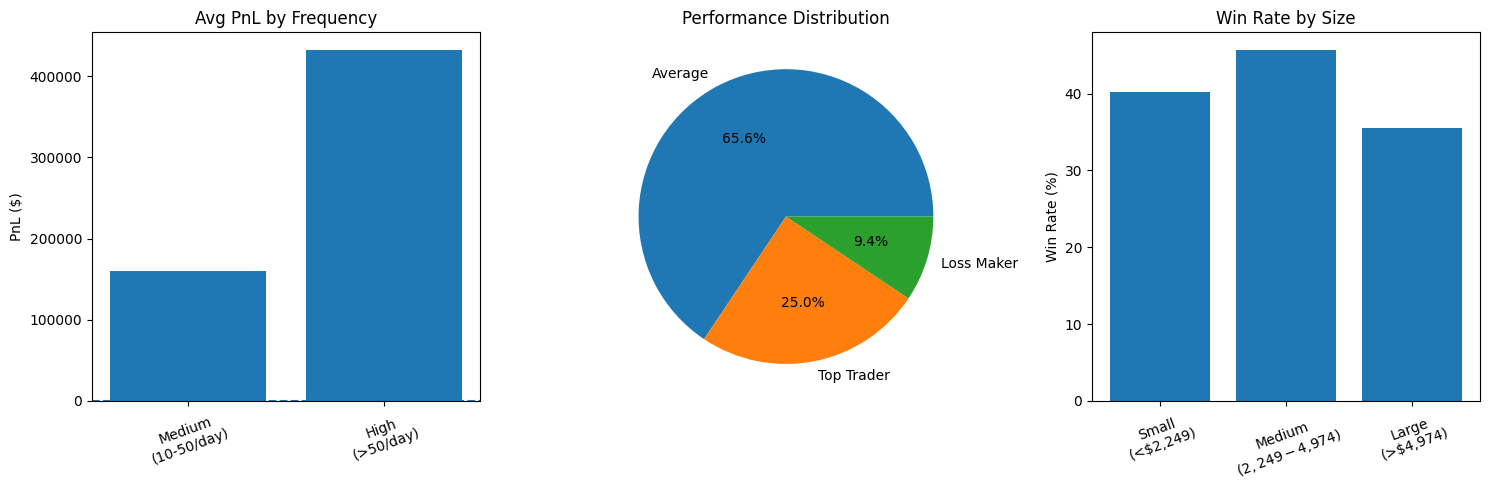

In [ ]:
# Chart 3 — Trader Segments
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Avg PnL by Frequency
freq_pnl = trader_stats.groupby('freq_segment')['total_pnl'].mean()

axes[0].bar(freq_pnl.index.astype(str), freq_pnl.values)
axes[0].axhline(0, linestyle='--')
axes[0].set_title('Avg PnL by Frequency')
axes[0].set_ylabel('PnL ($)')
axes[0].tick_params(axis='x', rotation=20)

# Performance Distribution
perf_counts = trader_stats['perf_segment'].value_counts()

axes[1].pie(perf_counts.values, labels=perf_counts.index, autopct='%1.1f%%')
axes[1].set_title('Performance Distribution')

# Win Rate by Trade Size
size_wr = trader_stats.groupby('size_segment')['win_rate_pct'].mean()

axes[2].bar(size_wr.index.astype(str), size_wr.values)
axes[2].set_title('Win Rate by Size')
axes[2].set_ylabel('Win Rate (%)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


### **Key Insight**

- **High-frequency traders earn ~2.7x more** than medium-frequency traders. The Low segment is practically invisible, meaning infrequent traders barely make any profit. This shows that on Hyperliquid, trading volume and consistency directly correlates with profitability — the more actively you trade, the more you earn.

- **Only 9.4% of traders are Loss Makers** — surprisingly healthy. 1 in 4 traders (25%) are Top Performers, which is quite high compared to traditional markets where typically less than 10% of retail traders profit consistently. This suggests Hyperliquid attracts skilled, experienced traders rather than casual retail participants.

- **Medium-size traders have the HIGHEST win rate (~45%)**, outperforming both small and large traders. Large traders ($4,974+) actually have the lowest win rate (~35%) — suggesting that sizing up too big hurts accuracy, possibly due to slippage, over-leverage, or taking riskier setups. The sweet spot is medium sizing for the best win consistency.

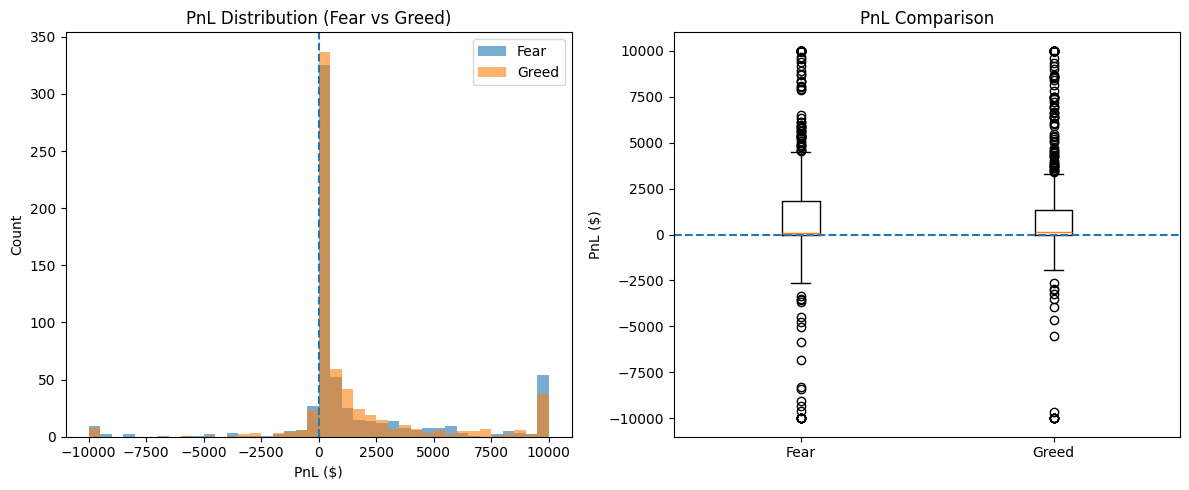

In [ ]:
# Chart 4 — PnL Distribution Fear vs Greed
# Limit extreme values
CLIP = 10000

fear_pnl = merged[merged['sentiment'] == 'Fear']['daily_pnl'].clip(-CLIP, CLIP)
greed_pnl = merged[merged['sentiment'] == 'Greed']['daily_pnl'].clip(-CLIP, CLIP)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(fear_pnl, bins=40, alpha=0.6, label='Fear')
axes[0].hist(greed_pnl, bins=40, alpha=0.6, label='Greed')

axes[0].axvline(0, linestyle='--')
axes[0].set_title('PnL Distribution (Fear vs Greed)')
axes[0].set_xlabel('PnL ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot
axes[1].boxplot([fear_pnl, greed_pnl], labels=['Fear', 'Greed'])

axes[1].axhline(0, linestyle='--')
axes[1].set_title('PnL Comparison')
axes[1].set_ylabel('PnL ($)')

plt.tight_layout()
plt.show()


### **Insights**

- **The overwhelming majority of daily PnL values are near 0** — most traders break even on most days. The distribution is extremely right-skewed, meaning big profits are rare but when they happen, they happen more on Fear days (the large blue bar at $10,000 clip limit shows Fear produces more extreme winners).

- **Median PnL is 0 for BOTH sentiments** — the typical trader barely profits or loses on any given day regardless of market mood. However, Fear days have a slightly higher 75th percentile (1,800 VS 1,500), meaning the top 25% of traders do better on Fear days than Greed days.

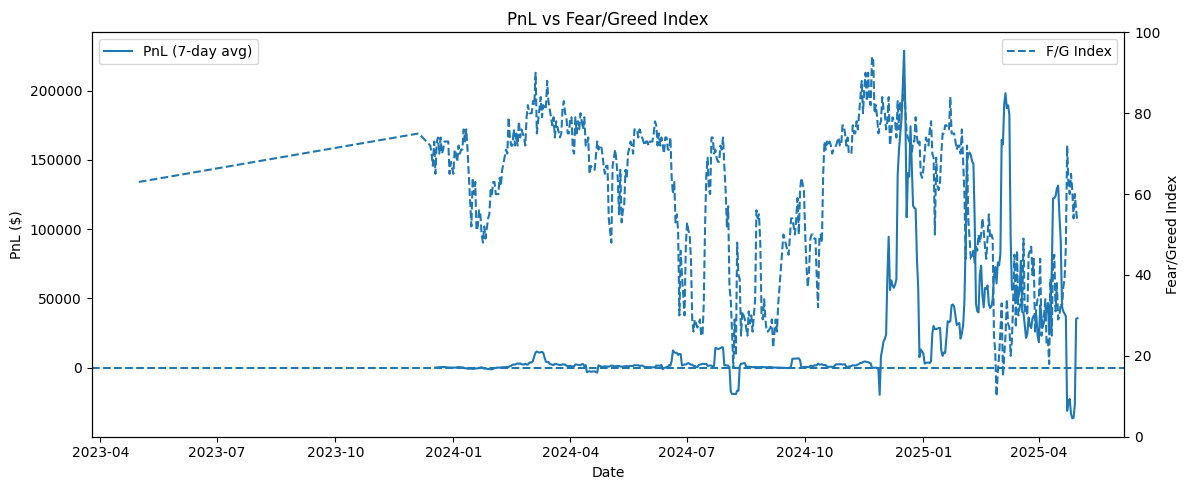

In [ ]:
# Chart 5 — Total PnL Over Time vs F/G Inde
#  Prepare data
daily_total = (
    merged.groupby('date')['daily_pnl'].sum().reset_index()
    .merge(fear[['date', 'value', 'sentiment']], on='date', how='left')
)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

# PnL (7-day average)
ax1.plot(
    daily_total['date'],
    daily_total['daily_pnl'].rolling(7).mean(),
    label='PnL (7-day avg)'
)

ax1.axhline(0, linestyle='--')
ax1.set_ylabel('PnL ($)')
ax1.set_xlabel('Date')

# Fear/Greed Index
ax2 = ax1.twinx()

ax2.plot(
    daily_total['date'],
    daily_total['value'],
    linestyle='--',
    label='F/G Index'
)

ax2.set_ylabel('Fear/Greed Index')
ax2.set_ylim(0, 100)

# Legend
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Title
plt.title('PnL vs Fear/Greed Index')

plt.tight_layout()
plt.show()

### **Key Insights**

1. **PnL and F/G Index move TOGETHER at the macro level**
The solid and dashed lines broadly follow each other — when greed rises, profits rise. When fear dominates, profits collapse.


2. **Extreme Greed = Maximum Profit Opportunity**
The Oct–Nov 2024 period (F/G index 85–95) produced the highest PnL ever (~$225K). Riding momentum during Extreme Greed is the most profitable macro strategy.


3. **Fear periods wipe out profits**
The Jun–Oct 2024 flat period shows that sustained Fear completely kills trader profitability at the aggregate level — most traders just can't profit in fearful markets.


4. **The first negative PnL appeared in 2025**
This is the only time in the dataset that aggregate PnL went below zero — happening as the market transitioned from Extreme Greed back to Fear in early 2025. Traders who held on too long from the bull run gave back profits.


5. Platform growth is visible
PnL was zero until late 2023, then grew massively — **showing Hyperliquid's rapid user growth in 2024**, not just market conditions driving the numbers.

# **Actionable Strategy**

- **Strategy 1 — Sentiment-Aware Position Sizing**

- Fear: Reduce position size by 30–40%. Avoid aggressive entries until sentiment improves.
- Greed: Use full position size. Momentum and trend-following strategies perform better.
- Neutral: Use standard position size. Enter only on clear setups.

- **Strategy 2 — Trading Frequency Control**

- Frequent traders: Reduce number of trades during Fear. Focus on fewer, high-quality trades.
- Infrequent traders: Increase activity during Greed. Momentum opportunities are stronger.

